In [1]:
import numpy as np
import plotly.graph_objects as go

import time
import pandas as pd
import json
from datetime import datetime
from datetime import timezone

import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy.signal import resample
from dtw import dtw

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Function

In [2]:
def read_json_from_ros2bag(json_file, print_ = True):
    list_of_length = []
    with open(json_file, 'r') as file:
        json_content = json.load(file)
    if print_:
        print('Read: ',json_file)
    for key, value in json_content.items():
        if print_:
            print(f"{key} range: {len(value)}")
        list_of_length.append(len(value))
    cut_data = {key: value[:min(list_of_length)] for key, value in json_content.items()}
    cut_df = pd.DataFrame(cut_data)
    return cut_df
def read_and_normalize_json_from_ros2bag(json_file, print_=True):
    list_of_length = []
    with open(json_file, 'r') as f:
        data = json.load(f)
    if print_:
        print('Read: ',json_file)
    for key, value in data.items():
        if print_:
            print(f"{key} range: {len(value)}")
        list_of_length.append(len(value))
    # Normalize the data into a DataFrame
    df = pd.json_normalize(data)
    return df

def process_sensor_data(input_df, sensor_key, output_column, window_slide=1, shift=0):
    sensor_val = []
    sensor_ts = []
    sensor_df = []

    for i in range(len(input_df[sensor_key][0])):
        sensor_val.append(input_df[sensor_key][0][i]['val'])
        sensor_ts.append(input_df[sensor_key][0][i]['ts'])

    sensor_df = pd.DataFrame(sensor_val, columns=output_column)
    sensor_df = sensor_df.shift(shift)
    sensor_df = sensor_df.rolling(window=window_slide).mean()
    sensor_df['ts'] = sensor_ts

    return sensor_df

def resample_gait_cycles_to_same_size(gait_a: np.ndarray, gait_b: np.ndarray):
    """
    Resample two gait cycles to have the same number of samples (matching the shorter one).
    Uses Fourier-based resampling (good for continuous signals).

    Parameters:
        gait_a (np.ndarray): First gait cycle (e.g., Slow)
        gait_b (np.ndarray): Second gait cycle (e.g., Fast)

    Returns:
        (np.ndarray, np.ndarray): Tuple of resampled (gait_a, gait_b)
    """
    if not isinstance(gait_a, np.ndarray) or not isinstance(gait_b, np.ndarray):
        raise TypeError("Both inputs must be NumPy arrays.")
    if gait_a.size == 0 or gait_b.size == 0:
        raise ValueError("Input arrays cannot be empty.")
    
    # Choose target length (match shorter one, or pick a desired fixed length)
    target_len = min(len(gait_a), len(gait_b))

    gait_a_resampled = resample(gait_a, target_len)
    gait_b_resampled = resample(gait_b, target_len)

    return gait_a_resampled, gait_b_resampled

# Load

In [3]:
df        = read_and_normalize_json_from_ros2bag('symetrical_walking_bag/subject1_OAIC_S38_4.json', print_=False)

shift = 0

window_slide = 1
sym_joint_cmd_df    = process_sensor_data(df, 'GaitStep',           ['RH','RK','RA','LH','LK','LA'], window_slide, shift)
sym_joint_fb_df     = process_sensor_data(df, 'JointAngles',        ['RH','RK','RA','LH','LK','LA'], window_slide, shift)
sym_foot_force_df   = process_sensor_data(df, 'FootPressure',       ['Rheel','Rtoe','Lheel','Ltoe'], window_slide, shift)

In [4]:
from gait_cycle_cut.gait_cycle_cut import GaitCycleDetector
gait_cycle_detector = GaitCycleDetector()
latest_gait_cycles = {}

for joint_angle, foot_force_heel, foot_force_toe in zip(sym_joint_fb_df['RH'], sym_foot_force_df['Rheel'], sym_foot_force_df['Rtoe']):
    gait_cycle_detector.process_step(joint_angle, foot_force_heel, foot_force_toe)

latest_gait_cycles['Slow2'] = gait_cycle_detector.get_gait_cycles()[3]
latest_gait_cycles['Slow']  = gait_cycle_detector.get_gait_cycles()[4]
latest_gait_cycles['Fast']  = gait_cycle_detector.get_gait_cycles()[6]

print(np.shape(latest_gait_cycles['Slow']))
print(np.shape(latest_gait_cycles['Fast']))

(3799,)
(4249,)


# DTW

DTW Distance: 25710.52359224718


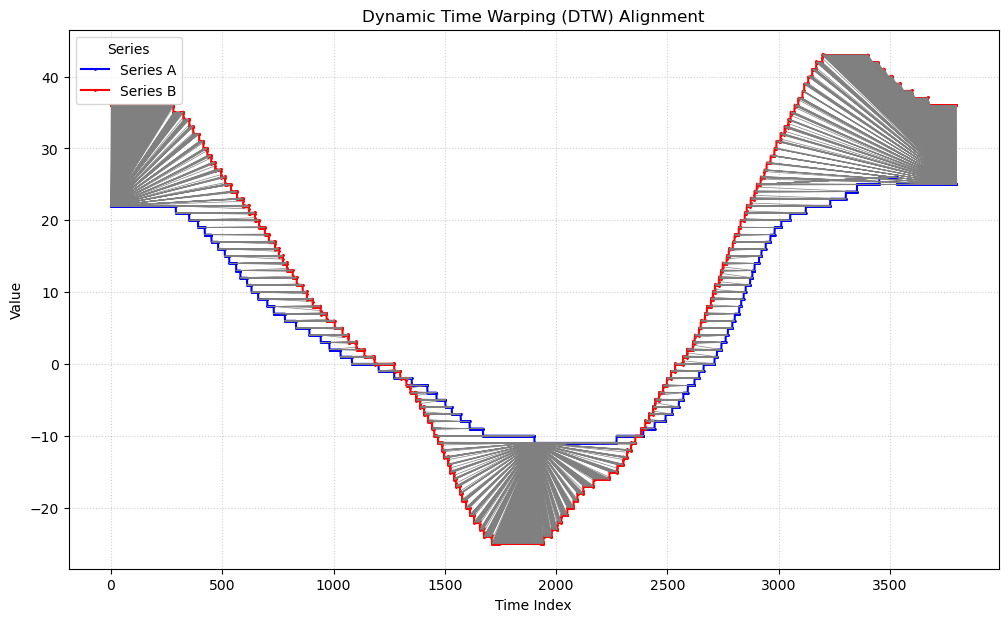

In [5]:


latest_gait_cycles['Slow'], latest_gait_cycles['Fast'] = resample_gait_cycles_to_same_size(np.array(latest_gait_cycles['Slow']), np.array(latest_gait_cycles['Fast']))

# Assuming 'latest_gait_cycles' is defined in your environment
series_a = latest_gait_cycles['Slow']
series_b = latest_gait_cycles['Fast']

alignment = dtw(series_a, series_b, keep_internals=True)
path_a = alignment.index1
path_b = alignment.index2
dtw_distance = alignment.distance
print(f"DTW Distance: {dtw_distance}")

# --- (Matplotlib Plotting Code) ---

# 1. Create a figure and axes
fig, ax = plt.subplots(figsize=(12, 7))

# 2. Plot Series A
ax.plot(np.arange(len(series_a)), series_a, 
        'bo-', # 'b' for blue, 'o' for markers, '-' for line
        label='Series A', 
        markersize=1)

# 3. Plot Series B
ax.plot(np.arange(len(series_b)), series_b, 
        'rD-', # 'r' for red, 'D' for diamond markers, '-' for line
        label='Series B', 
        markersize=1)

# 4. Plot the alignment lines (same loop as before)
for i, j in zip(path_a, path_b):
    ax.plot([i, j], [series_a[i], series_b[j]], 
            color='gray', 
            linestyle='-', # Use a dashed line
            linewidth=0.5)  # Thinner line

# 5. Update layout (using ax.set_ methods)
ax.set_title('Dynamic Time Warping (DTW) Alignment')
ax.set_xlabel('Time Index')
ax.set_ylabel('Value')
ax.legend(title='Series')
ax.grid(True, linestyle=':', alpha=0.6) # Add a light grid

# 6. Show the plot
plt.show()



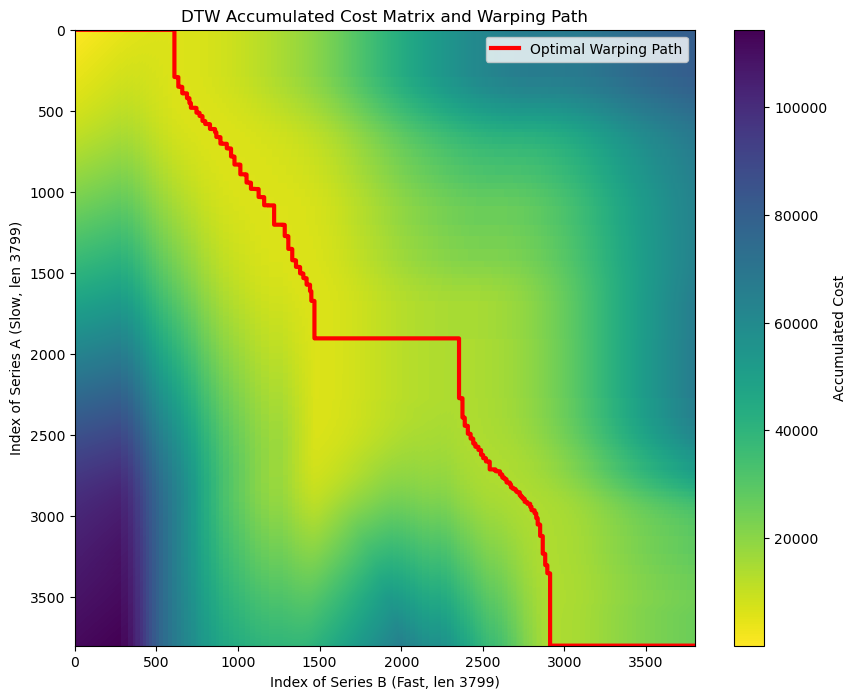

In [6]:

# --- (Your existing data and DTW setup) ---
# Assuming 'latest_gait_cycles', 'series_a', 'series_b', 
# 'alignment', 'path_a', and 'path_b' are already defined.
cost_matrix = alignment.costMatrix

# --- (Matplotlib Plotting Code) ---

# 1. Create a figure and axes
# We can set figsize to make it a bit wider
fig_matrix, ax = plt.subplots(figsize=(10, 8))

# 2. Add the heatmap
# 'imshow' is the matplotlib equivalent of go.Heatmap
# origin='upper' puts (0,0) at the top-left, matching your Plotly layout
# aspect='auto' allows the plot to be non-square
im = ax.imshow(cost_matrix, 
               cmap='viridis_r',  # '_r' reverses the colormap (like reversescale=True)
               origin='upper', 
               interpolation='nearest', 
               aspect='auto')

# 3. Add a colorbar
# This adds the color scale legend for the heatmap
cbar = fig_matrix.colorbar(im, ax=ax)
cbar.set_label('Accumulated Cost')

# 4. Add the optimal warping path trace
# 'plot' is the matplotlib equivalent of go.Scatter
ax.plot(path_b,  # Path indices for Series B
        path_a,  # Path indices for Series A
        color='red', 
        linewidth=3, 
        label='Optimal Warping Path')

# 5. Update layout
ax.set_title('DTW Accumulated Cost Matrix and Warping Path')
ax.set_xlabel(f'Index of Series B (Fast, len {len(series_b)})')
ax.set_ylabel(f'Index of Series A (Slow, len {len(series_a)})')
ax.legend()

# 6. Show the new plot
plt.show()

# RBF

In [7]:
from cpg_rbf.cpg_so2 import CPG_SO2
from cpg_rbf.rbf import RBF 

cpg = CPG_SO2()
rbf = RBF()

from scipy.interpolate import interp1d
# resample target
def resample_cycle(cycle, num_points):
    """Resamples a gait cycle to have a fixed number of points using interpolation."""
    original_indices = np.linspace(0, 1, len(cycle))  # original indices based on the length of the cycle
    new_indices = np.linspace(0, 1, num_points)  # new indices to match the desired number of points
    interpolation_function = interp1d(original_indices, cycle, kind='linear')  # interpolate the data
    return interpolation_function(new_indices)  # return the resampled cycle

def rotate_cyclic(df, column_name, range):
    # Move the last value to the first position using pd.concat()
    return pd.concat([df[column_name].iloc[-range:], df[column_name].iloc[:-range]]).reset_index(drop=True)

In [8]:
target_length = 10000

cpg_one_cycle = np.load('cpg_rbf/cpg_one_cycle.npz')
out0_cpg_one_cycle = resample_cycle(cpg_one_cycle['O0'], target_length)    
out1_cpg_one_cycle = resample_cycle(cpg_one_cycle['O1'], target_length)     

cpg_kernel = rbf.construct_kernels_with_cpg_one_cycle(out0_cpg_one_cycle, out1_cpg_one_cycle, target_length)

## Path 1

In [9]:
target_1 = resample_cycle(np.array(latest_gait_cycles['Slow']), target_length)     
target_1_length = len(target_1)

imitated_path_offline_1     = rbf.imitate_path_by_learning(target_1)

## Path 2

In [10]:
target_2 = resample_cycle(np.array(latest_gait_cycles['Fast']), target_length)     
target_2_length = len(target_2)
 
imitated_path_offline_2     = rbf.imitate_path_by_learning(target_2)

## Path 3 

In [ ]:
target_3 = resample_cycle(np.array(latest_gait_cycles['Slow2']), target_length)
target_3_length = len(target_3)
 
imitated_path_offline_3     = rbf.imitate_path_by_learning(target_3)

## Result

In [12]:
imitated_evolution      = rbf.get_evolution_learning_path()
imitated_error          = rbf.get_error_max_while_learning()
imitated_weight         = rbf.get_weight_while_learning()

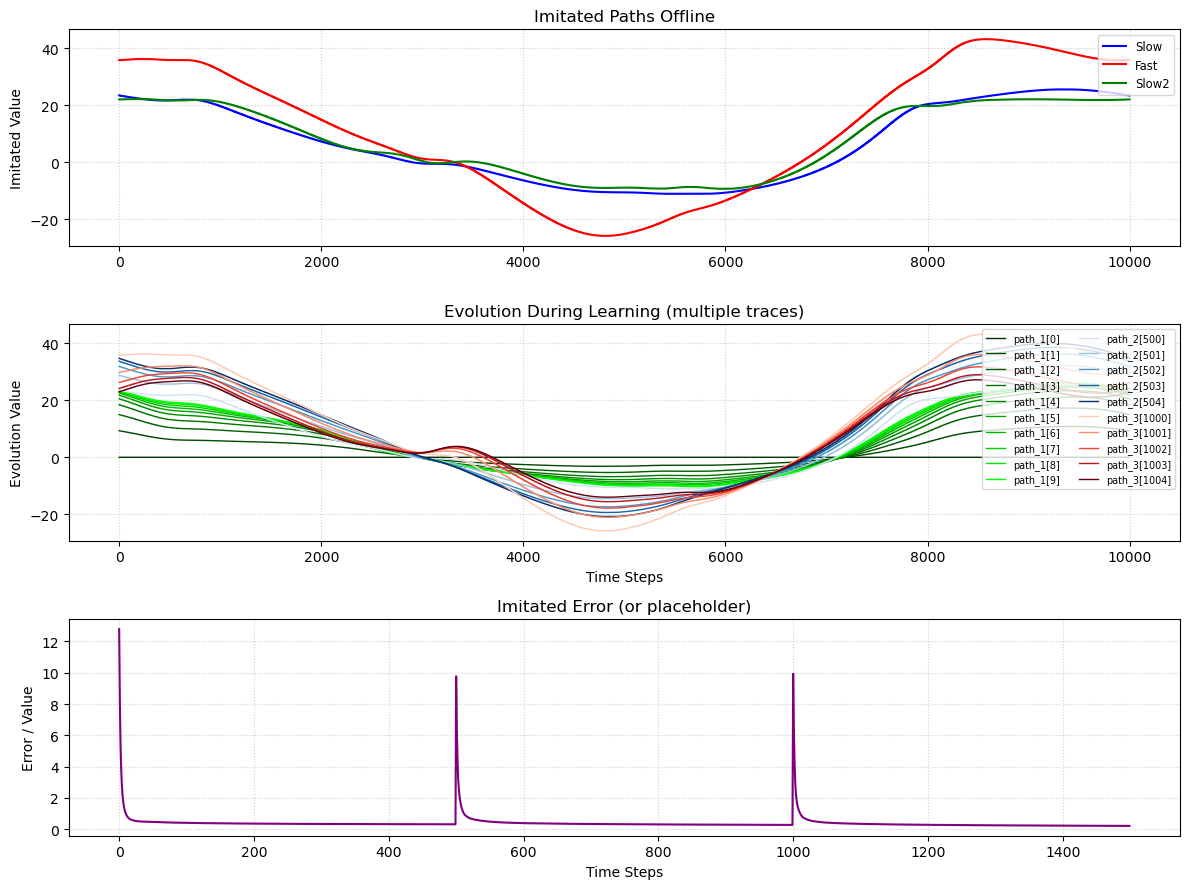

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)


# Top subplot: imitated offline paths (one per series)
axes[0].plot(imitated_path_offline_1, color='blue', label='Slow')
axes[0].plot(imitated_path_offline_2, color='red', label='Fast')
axes[0].plot(imitated_path_offline_3, color='green', label='Slow2')
axes[0].set_ylabel('Imitated Value')
axes[0].set_title('Imitated Paths Offline')
axes[0].legend(loc='upper right', fontsize='small')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Middle subplot: multiple evolution traces using gradients (matplotlib)
axes[1].set_title('Evolution During Learning (multiple traces)')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Evolution Value')

# Green gradient 
num_traces = 10
# Blue colormap traces 
green_gradient = [(0.0, (50 + i * (205.0 / (num_traces - 1))) / 255.0, 0.0, 1.0) for i in range(num_traces)]
for i in range(num_traces):
    if i < len(imitated_evolution):
        axes[1].plot(imitated_evolution[i], color=green_gradient[i], linewidth=1, label=f'path_1[{i}]')

# Blue colormap traces 
colors1 = plt.cm.Blues(np.linspace(0.2, 1, 5))
for idx, idx_data in enumerate(range(500, 505)):
    if idx_data < len(imitated_evolution):
        axes[1].plot(imitated_evolution[idx_data], color=colors1[idx], linewidth=1, label=f'path_2[{idx_data}]')

# Red colormap traces 
colors2 = plt.cm.Reds(np.linspace(0.2, 1, 5))
for idx, idx_data in enumerate(range(1000, 1005)):
    if idx_data < len(imitated_evolution):
        axes[1].plot(imitated_evolution[idx_data], color=colors2[idx], linewidth=1, label=f'path_3[{idx_data}]')

axes[1].legend(loc='upper right', fontsize='x-small', ncol=2)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Bottom subplot placeholder (keep for other plots)
axes[2].plot(imitated_error if 'imitated_error' in globals() else np.zeros(1), color='purple')
axes[2].set_xlabel('Time Steps')
axes[2].set_ylabel('Error / Value')
axes[2].set_title('Imitated Error (or placeholder)')
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

